### Hi-erachical clustering

The objective of the project is to group the customer.

So, we're using Hierarichal clustering to group the dataset into cluster.

In [1]:
# Importing the Necessary packages 

import pandas as pd # To handle large data
import matplotlib.pyplot as plt # To visualize the dataset
import seaborn as sns  # Advanced visulizing tool

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('clustering.csv')  # loading the dataset as data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      1000 non-null   int64  
 1   Annual_Income   1000 non-null   int64  
 2   Spending_Score  1000 non-null   float64
 3   Age             1000 non-null   int64  
 4   Region          1000 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 39.2+ KB


In [3]:
df.drop(columns=['CustomerID'], inplace=True)

In [4]:
df.Region.unique()

array(['North', 'West', 'East', 'South'], dtype=object)

In [5]:
df.head()

,Annual_Income,Spending_Score,Age,Region
0,67450,17.58,31,North
1,57926,11.35,27,West
2,69715,64.01,38,East
3,82845,70.94,48,North
4,56487,4.13,16,North


In [6]:
# Analytics about data 

df.describe()

,Annual_Income,Spending_Score,Age
count,1000.00000,1000.000000,1000.000000
mean,60289.47500,50.861300,34.631000
std,14688.23654,28.547316,9.700667
min,11380.00000,1.320000,4.000000
25%,50285.75000,25.475000,28.000000
50%,60379.00000,52.095000,35.000000
75%,69718.75000,74.887500,41.000000
max,117790.00000,99.940000,66.000000


In [7]:
# Checking for null or empty values

df.isnull().sum()

Annual_Income     0
Spending_Score    0
Age               0
Region            0
dtype: int64

In [8]:
# Checking for duplicates

df.duplicated().sum()

0

In [9]:
# Normalizing module to normalizr the qualitative non standard data 
  
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()


In [10]:
sc_quatitative_data = sc.fit_transform(df.drop(columns='Region'))

In [11]:
sc_qualitative_data = pd.get_dummies(df['Region']).astype('int')

In [12]:
sc_qualitative_data


,East,North,South,West
0,0,1,0,0
1,0,0,0,1
2,1,0,0,0
3,0,1,0,0
4,0,1,0,0
...,...,...,...,...
995,0,0,1,0
996,1,0,0,0
997,1,0,0,0
998,0,0,1,0


In [13]:
data = pd.concat([pd.DataFrame(sc_quatitative_data, columns=['Annual_income', 'Spending_score', 'Age']), sc_qualitative_data], axis=1)

In [14]:
data.head()

,Annual_income,Spending_score,Age,East,North,South,West
0,0.487745,-1.166413,-0.374491,0,1,0,0
1,-0.160990,-1.384756,-0.787041,0,0,0,1
2,0.642027,0.460824,0.347469,1,0,0,0
3,1.536387,0.703700,1.378842,0,1,0,0
4,-0.259008,-1.637796,-1.921551,0,1,0,0


In [15]:
# Import the packages for clustering
from scipy.cluster.hierarchy import linkage,fcluster,dendrogram

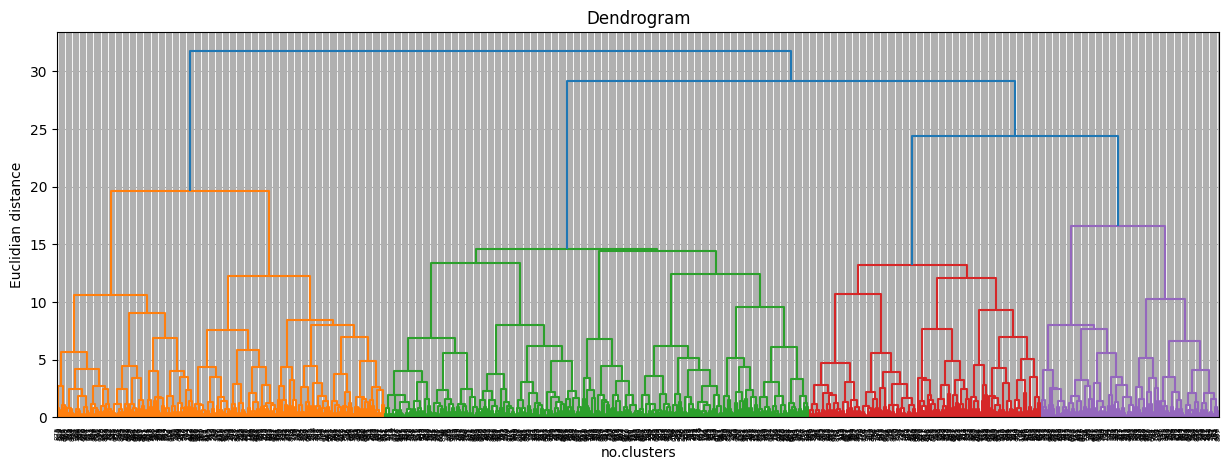

In [16]:
# Visualizing the dendogram

plt.figure(figsize=(15,5))
dendrogram(linkage(data,method='ward'))
plt.xlabel('no.clusters')
plt.ylabel('Euclidian distance')
plt.title('Dendrogram')
plt.grid(True)
plt.show()

In [17]:
# Computing linkage to build dendogram

link = linkage(data, method='ward') #ward method to reduce variance

In [18]:
# Assigning cluster labels

cluster  = fcluster(link, t = 4, criterion='maxclust') # maxclust to form exactly `t` no.of cluster

In [19]:
# Adding predicted cluster groups to the DataFrame
df['cluster'] = cluster

In [20]:
df.head()

,Annual_Income,Spending_Score,Age,Region,cluster
0,67450,17.58,31,North,3
1,57926,11.35,27,West,1
2,69715,64.01,38,East,2
3,82845,70.94,48,North,3
4,56487,4.13,16,North,1


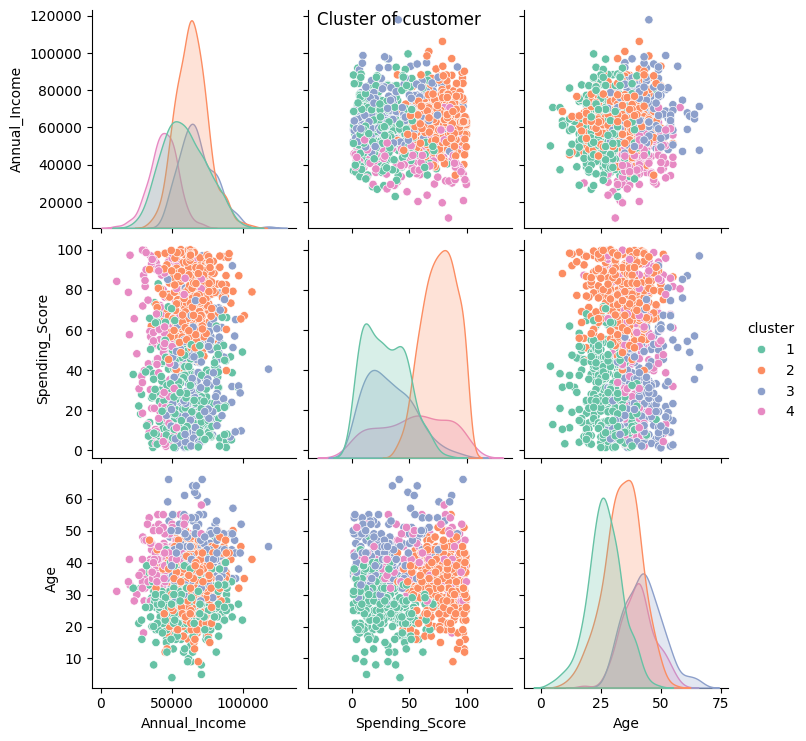

In [21]:
sns.pairplot(df, hue='cluster', vars=['Annual_Income',	'Spending_Score',	'Age'],palette='Set2')
plt.suptitle('Cluster of customer')
plt.show()

In [22]:
# Importing ploty library to visualize in 3D
import plotly.express as px

In [23]:
fig = px.scatter_3d(df, x='Annual_Income',y='Spending_Score',z='Age', color='cluster', hover_name='cluster', title='3D visulization')
fig.update_layout(scene=dict(xaxis_title='Annaul_income',yaxis_title='Spending_Score',zaxis_title='Age'),width=700,height=700)
fig.show()